In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%reload_ext autoreload
%autoreload 2

print("cwd:", Path.cwd())
print("sys.path:", sys.path[:5])

from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.sampling import ParameterSampler
from src.injection import SignalInjector

cwd: /home/victor/gw/cbc_pe/notebooks
sys.path: ['/home/victor/gw/cbc_pe', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '']


## SimulationConfig

In [2]:
config = SimulationConfig()

print("sampling_frequency (Hz):", config.sampling_frequency)
print("duration (s):", config.duration)
print("delta_t (s):", config.delta_t)
print("length:", config.length)
print("delta_f (Hz):", config.delta_f)
print("flength:", config.flength)

sampling_frequency (Hz): 4096.0
duration (s): 4.0
delta_t (s): 0.000244140625
length: 16384
delta_f (Hz): 0.25
flength: 8193


## CBCParameters

In [3]:
params = CBCParameters(
    mass_1=20.0,
    mass_2=40.0,
    distance=500.0,
    inclination=np.pi / 3,
    ra=1.2,
    dec=0.4,
    spin_1z=0.3,
    spin_2z=-0.2,
)

print(params)
print("mass_1 (Msun):", params.mass_1)
print("mass_2 (Msun):", params.mass_2)
print("total_mass (Msun):", params.total_mass)
print("chirp_mass (Msun):", params.chirp_mass)
print("chi_eff:", params.chi_eff)

CBCParameters(mass_1=40.0, mass_2=20.0, distance=500.0, inclination=1.0471975511965976, ra=1.2, dec=0.4, spin_1z=-0.2, spin_2z=0.3)
mass_1 (Msun): 40.0
mass_2 (Msun): 20.0
total_mass (Msun): 60.0
chirp_mass (Msun): 24.334573675728226
chi_eff: -0.03333333333333333


## ParameterSampler

In [4]:
sampler = ParameterSampler(rng=np.random.default_rng(42))
samples = sampler.sample_many(50000)

print(type(samples[0]))
print(samples[0])

mass_1 = np.array([s.mass_1 for s in samples])
mass_2 = np.array([s.mass_2 for s in samples])
inclinations = np.array([s.inclination for s in samples])
ras = np.array([s.ra for s in samples])
decs = np.array([s.dec for s in samples])

print(np.all(mass_1 >= mass_2))
print(ras.min(), ras.max())
print(decs.min(), decs.max())
print(inclinations.min(), inclinations.max())

<class 'src.parameters.CBCParameters'>
CBCParameters(mass_1=70.78626412725689, mass_2=42.30466737892445, distance=4321.270015574636, inclination=np.float64(1.1650157632181057), ra=0.5917337285168199, dec=np.float64(1.2572466191009846), spin_1z=0.5222794039807059, spin_2z=0.5721286105539076)
True
2.9236616297589228e-05 6.283080156358749
-1.5558382454793735 1.5634006339527045
0.009587441437286907 3.1304001449481835


### Isotropic checks for cos(i) and sin(dec)

<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:7: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_231162/1952523643.py:7: SyntaxWarning: invalid escape sequence '\i'
  ax[0].set_title(f"cos($\iota$)")


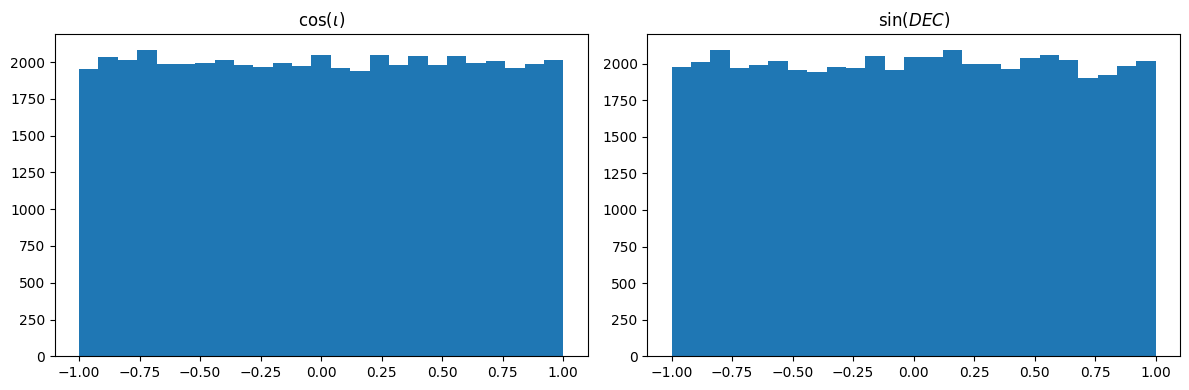

In [5]:
cos_i = np.cos(inclinations)
sin_dec = np.sin(decs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(cos_i, bins=25)
ax[0].set_title(f"cos($\iota$)")

ax[1].hist(sin_dec, bins=25)
ax[1].set_title(f"sin($\tDEC$)")

plt.tight_layout()
plt.show()

## SignalInjector

InjectionResult(strain=<pycbc.types.timeseries.TimeSeries object at 0x759a7e073f20>, injection_time=np.float64(0.953857421875), injection_index=np.int64(3907))


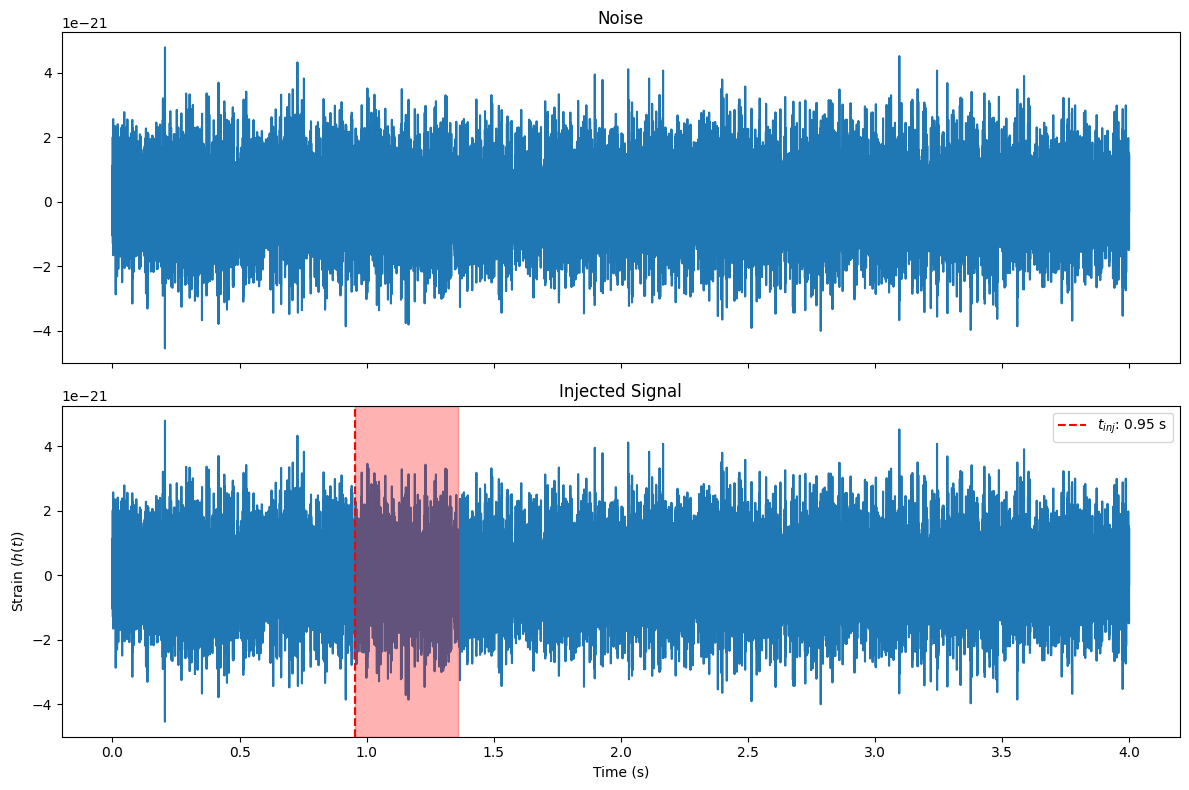

In [6]:
from src.noise import NoiseModel
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector

import lal as _lal

noise_model = NoiseModel(config=config)
noise = noise_model.sample(detector_name="V1")

waveform_generator = WaveformGenerator(config=config)
hp, hc = waveform_generator.generate(parameters=params)

detector_projector = DetectorProjector()
projected_signal = detector_projector.project(h_plus=hp, h_cross=hc, parameters=params)

signal_injector = SignalInjector(config=config)
injected_signal = signal_injector.inject(strain=noise, signal=projected_signal["V1"])

############### PLOTTING ###############

print(injected_signal)
t = np.arange(config.length) * config.delta_t

# plot the noise, signal, and injected signal
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t, noise)   
ax[0].set_title("Noise")


ax[1].plot(t, injected_signal.strain)
ax[1].set_title("Injected Signal")
# Band with the duration of the signal above the injected signal plot
ax[1].axvspan(
    injected_signal.injection_time,
    injected_signal.injection_time + len(projected_signal["V1"])*projected_signal["V1"].delta_t,
    color='red',
    alpha=0.3,
    zorder=2)
ax[1].axvline(injected_signal.injection_time, color='red', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Strain ($h(t)$)")
ax[1].legend()

# Vertical line at the injection time
plt.tight_layout()
plt.show()



## SignalProcessor

In [7]:
from src.processing import SignalProcessor

processor = SignalProcessor(
    config=config,
    apply_whitening=True,
    apply_lowpass=True,
    apply_highpass=True,
    apply_standardization=True,
    preserve_length=True,
    lowpass_frequency=350.0,
    highpass_frequency=30.0,
)



processed_signal = processor.process(injected_signal.strain)
print(type(processed_signal))
print(len(injected_signal.strain), len(processed_signal))
print("injected_signal.delta_f:",injected_signal.strain.delta_f)
print("injected_signal.delta_t:",injected_signal.strain.delta_t)
print("processed_signal.delta_f:",processed_signal.delta_f)
print("processed_signal.duration:",processed_signal.duration)
print("injected_signal.strain.duration:",injected_signal.strain.duration)

print("original start_time:", injected_signal.strain.start_time)
print("processed start_time:", processed_signal.start_time)
print("crop left time:", processed_signal.start_time - injected_signal.strain.start_time)

left_crop_samples = int(((processed_signal.start_time - injected_signal.strain.start_time) / processed_signal.delta_t))
print("left_crop_samples:", left_crop_samples)

print("original start_time:", injected_signal.strain.start_time)
print("processed start_time:", processed_signal.start_time)
print("original length:", len(injected_signal.strain))
print("processed length:", len(processed_signal))



<class 'pycbc.types.timeseries.TimeSeries'>
16384 16384
injected_signal.delta_f: 0.25
injected_signal.delta_t: 0.000244140625
processed_signal.delta_f: 0.25
processed_signal.duration: 4.0
injected_signal.strain.duration: 4.0
original start_time: 0
processed start_time: 0
crop left time: 0
left_crop_samples: 0
original start_time: 0
processed start_time: 0
original length: 16384
processed length: 16384


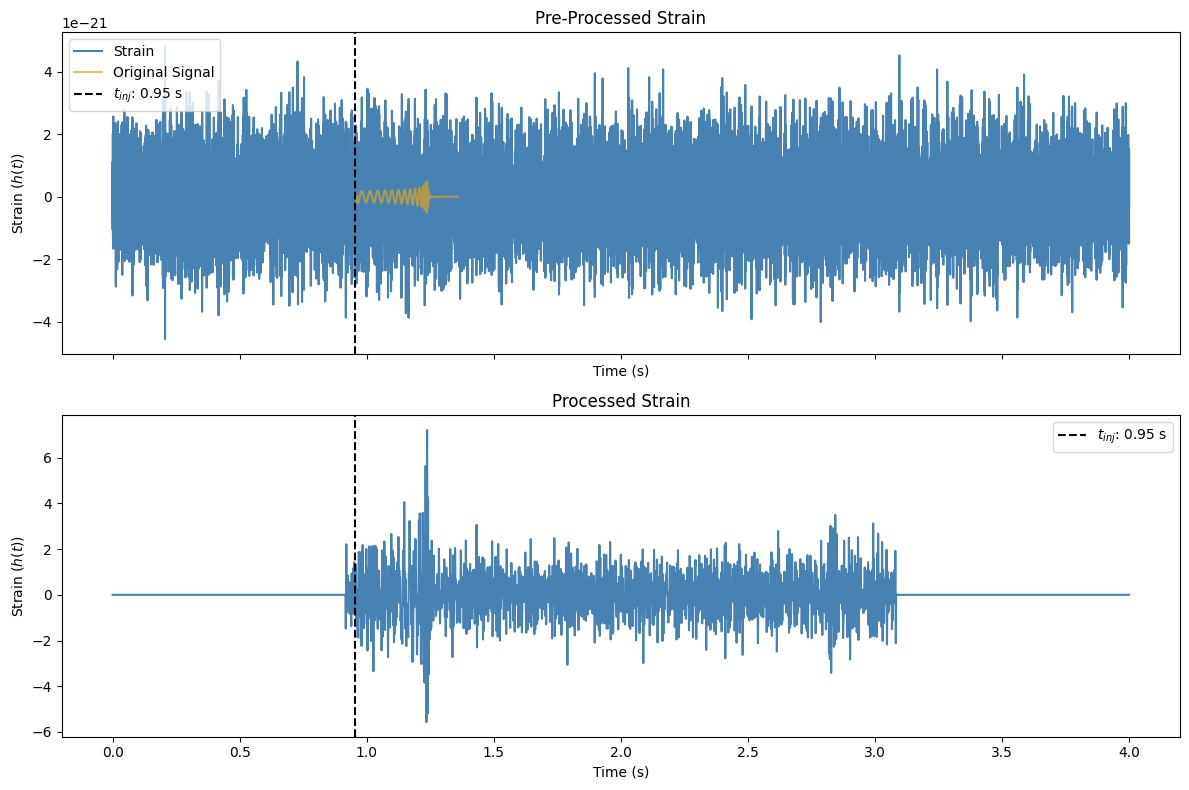

In [8]:
############### PLOTTING ###############

t = np.arange(config.length) * config.delta_t
t_processed = np.arange(len(processed_signal)) * processed_signal.delta_t + processed_signal.start_time
t_projected = np.arange(len(projected_signal["V1"])) * projected_signal["V1"].delta_t + injected_signal.injection_time

# plot the noise, signal, and injected signal
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t, injected_signal.strain, color='steelblue', label="Strain")  
ax[0].plot(t_projected, projected_signal["V1"], color='goldenrod', linestyle='-', alpha=0.7, label="Original Signal") 
ax[0].set_title("Pre-Processed Strain")
ax[0].axvline(injected_signal.injection_time, color='k', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Strain ($h(t)$)")
ax[0].legend()

ax[1].plot(t_processed, processed_signal, color='steelblue')
ax[1].set_title("Processed Strain")
ax[1].axvline(injected_signal.injection_time, color='k', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Strain ($h(t)$)")
ax[1].legend()

# Vertical line at the injection time
plt.tight_layout()
plt.show()
plt.close()

## Generating one-sample

In [23]:
from src.config import SimulationConfig
from src.dataset import DatasetBuilder

config = SimulationConfig()
builder = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=True,
        apply_standardization=True,
        preserve_length=True,
        lowpass_frequency=350.0,
        highpass_frequency=30.0,
    ),
)

sample = builder.build_sample()

print(type(builder))
print(sample.X.shape)
print(sample.y.shape)
print(sample.parameters)
print(type(sample.parameters))


# Check if signal processor arguments are correctly applied
builder = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=False,
        preserve_length=True,
    ),
)

print(builder.signal_processor.apply_whitening)
print(builder.signal_processor.apply_lowpass)
print(builder.signal_processor.apply_highpass)
print(builder.signal_processor.preserve_length)


# Check if label transformer arguments are correctly applied
mean = np.array([10.0, 20.0, 0.0])
std = np.array([2.0, 5.0, 0.5])

builder = DatasetBuilder.from_config(
    config=config,
    label_transformer_kwargs=dict(mean=mean, std=std),
)

print(builder.label_transformer.mean)
print(builder.label_transformer.std)

# Check if preserve ordering of detectors name
builder = DatasetBuilder.from_config(
    config=config,
    detector_names=["V1", "H1"],
    signal_processor_kwargs=dict(preserve_length=True),
)

print(builder.detector_names)

sample = builder.build_sample()
print(sample.X.shape)

<class 'src.dataset.DatasetBuilder'>
(3, 16384)
(3,)
CBCParameters(mass_1=56.40640809262792, mass_2=32.97184886229501, distance=3666.01769298541, inclination=np.float64(0.3256823064799591), ra=3.9958553703925626, dec=np.float64(0.670999277525061), spin_1z=-0.7025639070602112, spin_2z=-0.44959099148101367)
<class 'src.parameters.CBCParameters'>
True
True
False
True
[10. 20.  0.]
[2.  5.  0.5]
['V1', 'H1']
(2, 16384)


In [ ]:
# Check for reproducibility with rng
rng1 = np.random.default_rng(123)
rng2 = np.random.default_rng(123)

builder1 = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=True,
        apply_standardization=True,
        preserve_length=True,
    ),
    rng=rng1,
)

builder2 = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=True,
        apply_standardization=True,
        preserve_length=True,
    ),
    rng=rng2,
)

sample1 = builder1.build_sample()
sample2 = builder2.build_sample()

print(np.allclose(sample1.X, sample2.X))  #The noise introduced doesnt include a seed, all other physical parameters are reproducible
print(np.allclose(sample1.y, sample2.y))
print(sample1.parameters == sample2.parameters)

False
True
True


## ... and multiple samples

In [ ]:
batch = builder.build_dataset(num_samples=10)

print(batch.X.shape)
print(batch.y.shape)
print(batch.parameters[0])
print(len(batch.parameters))
print(type(batch.parameters[0]))

(10, 3, 16384)
(10, 3)
[CBCParameters(mass_1=78.78315636253815, mass_2=19.887917353556027, distance=1289.829956518386, inclination=np.float64(1.1553712113537746), ra=3.859902507595873, dec=np.float64(1.0475215309313817), spin_1z=0.30426405390220146, spin_2z=0.8093862451208114), CBCParameters(mass_1=83.77986447865986, mass_2=54.58920676951939, distance=1721.6128416887916, inclination=np.float64(0.528431021361852), ra=4.869258314638071, dec=np.float64(-1.3062901133919458), spin_1z=-0.7975981035624939, spin_2z=0.0981808033905256), CBCParameters(mass_1=26.1891748731711, mass_2=8.534575141969114, distance=4783.861116548713, inclination=np.float64(1.2891988988024392), ra=0.9172423555959305, dec=np.float64(-0.9259932443031844), spin_1z=0.8222895275252657, spin_2z=0.27703189584107557)]
10
<class 'src.parameters.CBCParameters'>


### TO DO LIST:
- Implementar una configuracion en la que se puede generar la dataset en un intervalo SNR reajustando consecuentemente la distancia (como el trabajo original)
- Decidir que tipo de input uso para la NN. 
    - Originalmente, CNN pero dando time-series. Si uso TS podría mirar otro tipo de arquitecturas mejor que CNN, quizá TCN (temporal), RNN o LSTMs. (MQRNN ?)
    - Quizá un spectrogtama con CNN podría ser más efectivo, o explorar otras arquitecturas. (NODE ? :  https://arxiv.org/abs/1806.07366)

# Mondrian (conformal binning) example

In [4]:
import numpy as np
from src.conformal.binning import PredictionBinner

signal_length = 10
predictions = np.transpose(np.array([np.random.rand(signal_length)*10, np.random.rand(signal_length)*100, np.random.rand(signal_length)*10 + 45])) 
n_bins = 5
print("predictions shape:", predictions.shape)
#print("predictions:", predictions)

prediction_binner = PredictionBinner(n_bins=n_bins)
predictions_bins = prediction_binner.fit(predictions)

print("predictions_bins.bin_edges shape:", predictions_bins.bin_edges.shape)
print("predictions_bins.bin_edges:", predictions_bins.bin_edges[:,0])

bin_indices = predictions_bins.transform(predictions)

print("bin_indices shape:", bin_indices.shape)
#print("bin_indices:", bin_indices)
print("Has Failed:", np.any(bin_indices >= n_bins))

##################################################

calibration_set = np.transpose(np.array([np.random.rand(signal_length)*10, np.random.rand(signal_length)*100, np.random.rand(signal_length)*10 + 45]))
test_set = np.transpose(np.array([np.random.rand(signal_length)*10-10, np.random.rand(signal_length)*100+100, np.random.rand(signal_length)*10 + 45]))
print("calibration_set shape:", calibration_set.shape)
print("test_set shape:", test_set.shape)

print("calibration_set:", calibration_set[:,0])
print("test_set:", test_set[:,0])

calibration_set_bins = prediction_binner.transform(calibration_set)

print("calibration_set_bins shape:", calibration_set_bins.shape)
#print("calibration_set_bins:", calibration_set_bins)

test_set_bins = prediction_binner.transform(test_set)

print("test_set_bins shape:", test_set_bins.shape)
#print("test_set_bins:", test_set_bins)

bin_indices = predictions_bins.transform(test_set)

print("bin_indices shape:", bin_indices.shape)
print("bin_indices:", bin_indices)
print("Has Failed:", np.any(bin_indices >= n_bins))




predictions shape: (10, 3)
predictions_bins.bin_edges shape: (6, 3)
predictions_bins.bin_edges: [3.40643919 4.12007888 5.46153858 6.37591843 6.73519559 8.87514115]
bin_indices shape: (10, 3)
Has Failed: False
calibration_set shape: (10, 3)
test_set shape: (10, 3)
calibration_set: [4.49435569 8.28698498 4.66740718 5.50427894 7.57742336 9.58815174
 1.28494029 2.14617734 9.74802897 9.87702675]
test_set: [-4.51076766 -0.79440336 -1.04104063 -2.01848762 -4.36664948 -6.96377024
 -2.29326495 -0.63456809 -5.01953874 -4.25546563]
calibration_set_bins shape: (10, 3)
test_set_bins shape: (10, 3)
bin_indices shape: (10, 3)
bin_indices: [[0 4 0]
 [0 4 2]
 [0 4 2]
 [0 4 0]
 [0 4 4]
 [0 4 1]
 [0 4 4]
 [0 4 0]
 [0 4 0]
 [0 4 2]]
Has Failed: False


In [ ]:
from src.conformal.binning import BinGrouper

predictions =np.array([[10, 100, 1000], [20, 200, 2000 ], [30, 300, 3000], [40, 400, 4000]])
bin_indices = np.array([[0, 1, 0], [0, 0, 1], [1, 1, 1], [1, 0, 1]])

print("predictions:\n", predictions)
print("bin_indices:\n", bin_indices)

print("predictions shape:", predictions.shape)
print("bin_indices shape:", bin_indices.shape)

ba = BinGrouper(n_bins=2)
binned_predictions = ba.group_by_bin(predictions, bin_indices)

#print("binned_predictions shape:", binned_predictions.shape)
print("binned_predictions:\n", binned_predictions)




predictions:
 [[  10  100 1000]
 [  20  200 2000]
 [  30  300 3000]
 [  40  400 4000]]
bin_indices:
 [[0 1 0]
 [0 0 1]
 [1 1 1]
 [1 0 1]]
predictions shape: (4, 3)
bin_indices shape: (4, 3)
binned_predictions:
 [[array([10, 20]), array([30, 40])], [array([200, 400]), array([100, 300])], [array([1000]), array([2000, 3000, 4000])]]


In [ ]:

import numpy as np
np.set_printoptions(threshold=np.inf, linewidth=200)

predictions =np.array([[10, 100, 1000], [20, 200, 2000 ], [30, 300, 3000], [40, 400, 4000]]) #(4,3)
bin_indices = np.array([[0, 1, 0], [0, 0, 1], [1, 1, 1], [1, 0, 1]]) #(4,3) samples, labels
intervals_ = ([np.array([-0.1, 0.1]), np.array([-0.3,0.3])],
                       [np.array([-0.4, 0.4]), np.array([-0.15,0.15])],
                       [np.array([-0.1, 0.1]), np.array([-0.2,0.2])]
                       ) #labels, nbins, 2 (3, nbins, 2) nbins = 2

n_bins = len(intervals_[0])
n_labels = len(intervals_)
prediction_with_lower = np.empty(predictions.shape, dtype=float)  # (n_samples, n_labels)
prediction_with_upper = np.empty(predictions.shape, dtype=float)

print("predictions:\n", predictions)
print("bin_indices:\n", bin_indices)
print("n_bins:", n_bins)

print("predictions shape:", predictions.shape)
print("bin_indices shape:", bin_indices.shape)
print("n_labels:", n_labels)
print("intervals_.shape:", intervals_[0][0][0])
print("bin_indices[:, 0]:", bin_indices[:, 0])

for n in range(n_labels):
    for m in range(n_bins):
        prediction_with_lower[:, n] = predictions[:, n] + intervals_[n][bin_indices[m, n]][0] 
        prediction_with_upper[:, n] = predictions[:, n] + intervals_[n][bin_indices[m, n]][1] 

for i in range(n_labels):
    print("label:", i)
    #Make to show the whole result in the output the following
    print("prediction_with_lower[:, i]:\n", prediction_with_lower[:, i].tolist()) 
    print("prediction_with_upper[:, i]:\n", prediction_with_upper[:, i].tolist()) 

predictions:
 [[  10  100 1000]
 [  20  200 2000]
 [  30  300 3000]
 [  40  400 4000]]
bin_indices:
 [[0 1 0]
 [0 0 1]
 [1 1 1]
 [1 0 1]]
n_bins: 2
predictions shape: (4, 3)
bin_indices shape: (4, 3)
n_labels: 3
intervals_.shape: -0.1
bin_indices[:, 0]: [0 0 1 1]
label: 0
prediction_with_lower[:, i]:
 [9.9, 19.9, 29.9, 39.9]
prediction_with_upper[:, i]:
 [10.1, 20.1, 30.1, 40.1]
label: 1
prediction_with_lower[:, i]:
 [99.6, 199.6, 299.6, 399.6]
prediction_with_upper[:, i]:
 [100.4, 200.4, 300.4, 400.4]
label: 2
prediction_with_lower[:, i]:
 [999.8, 1999.8, 2999.8, 3999.8]
prediction_with_upper[:, i]:
 [1000.2, 2000.2, 3000.2, 4000.2]
